In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

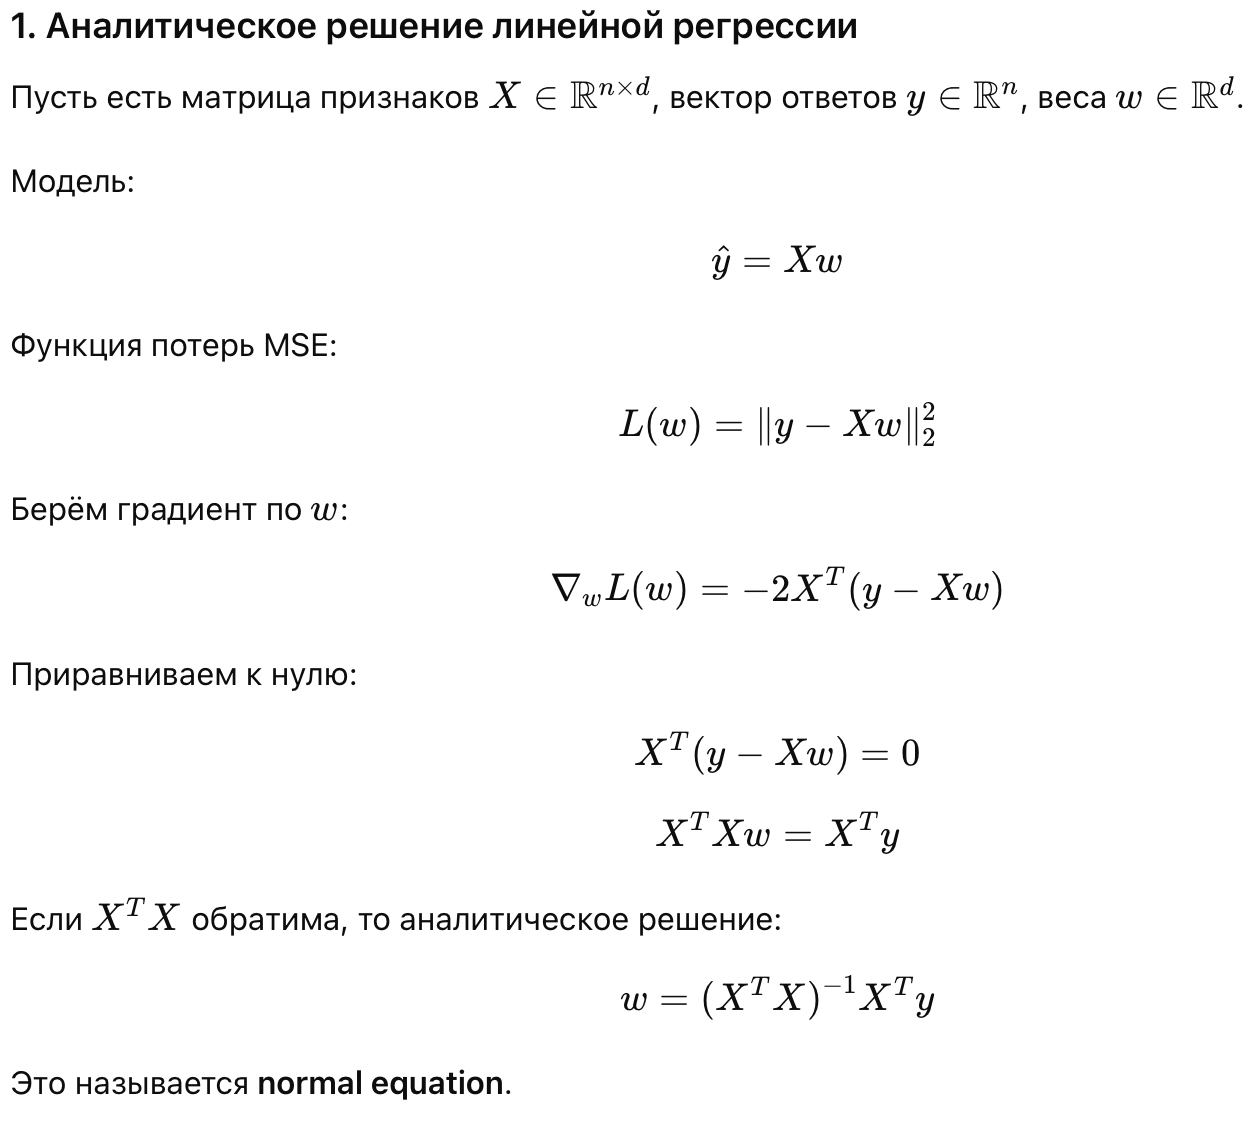
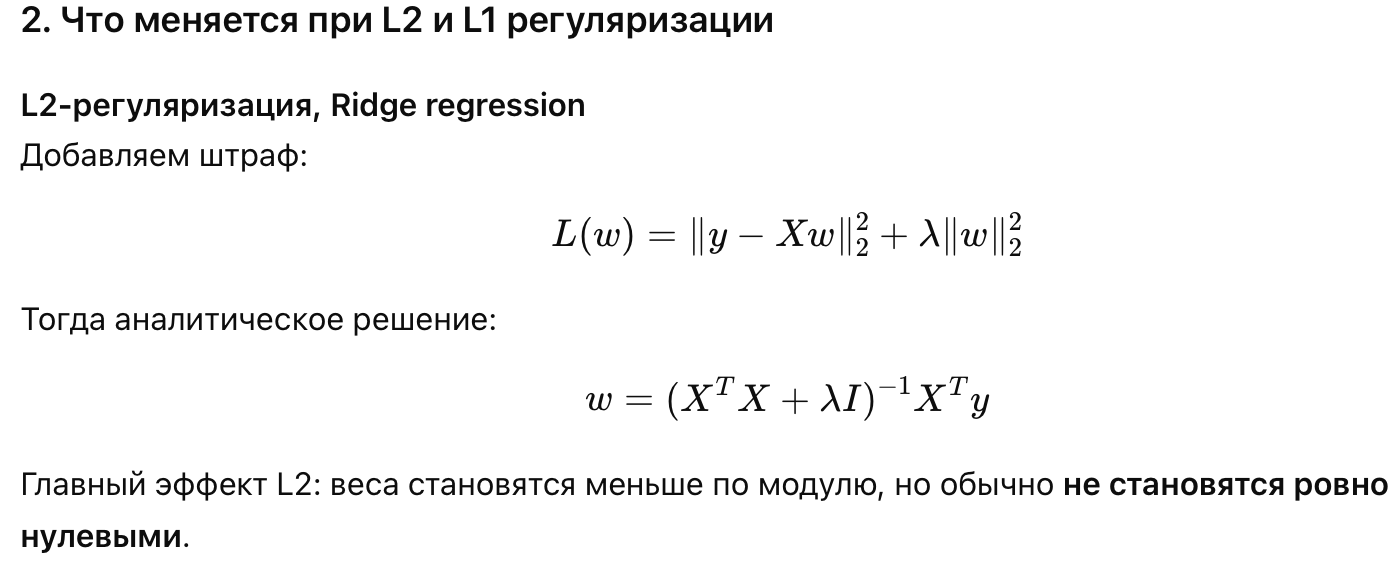
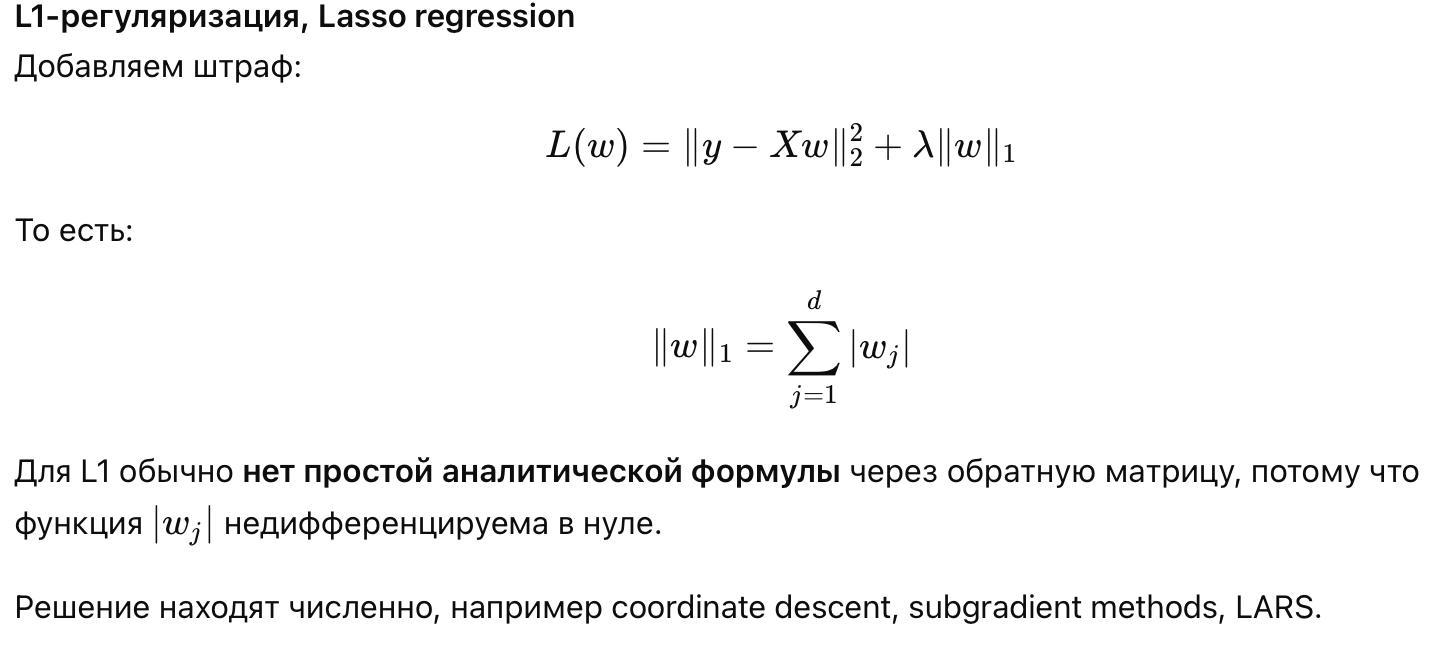
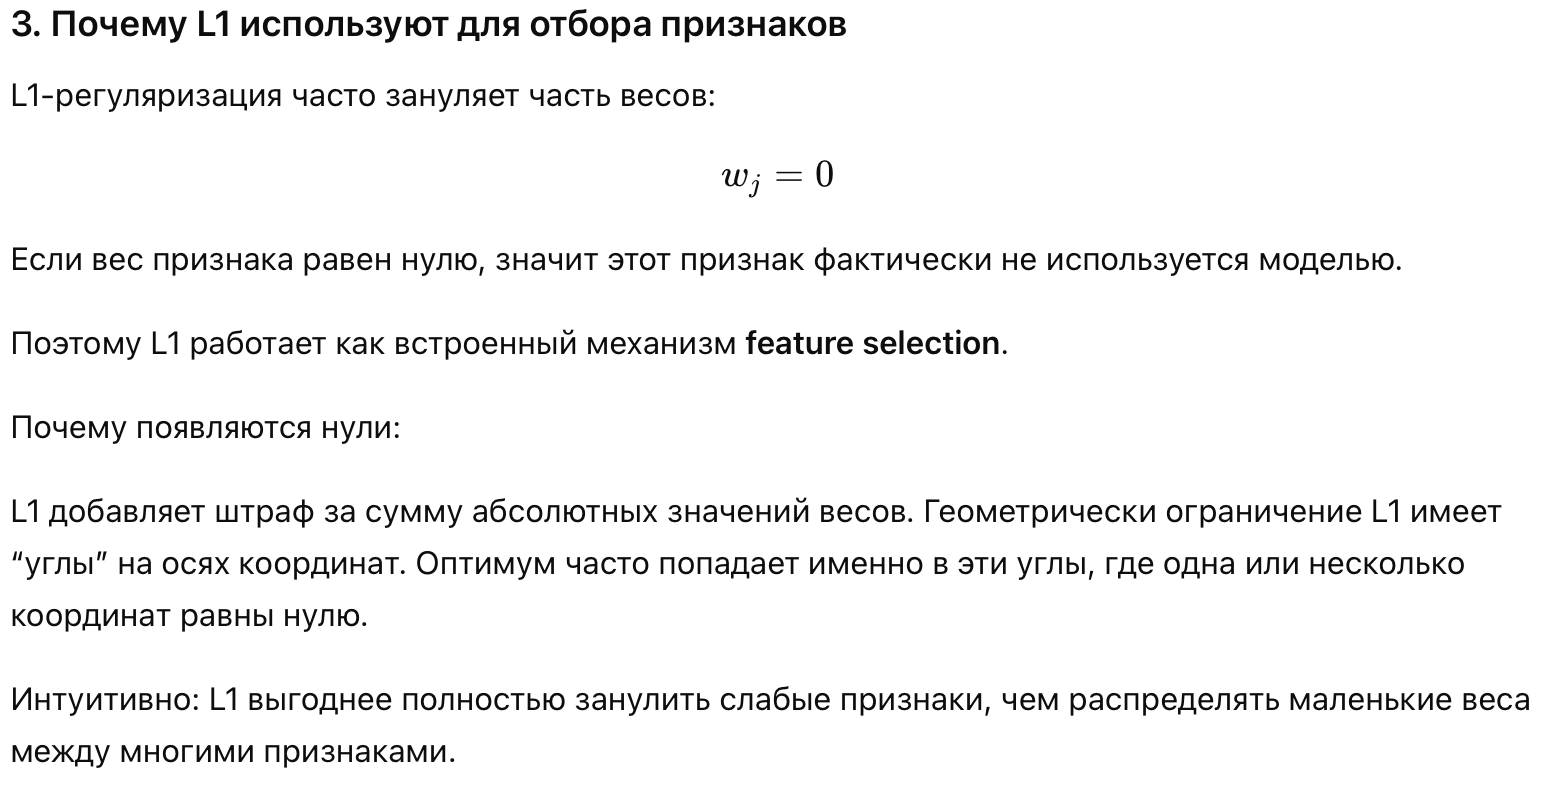
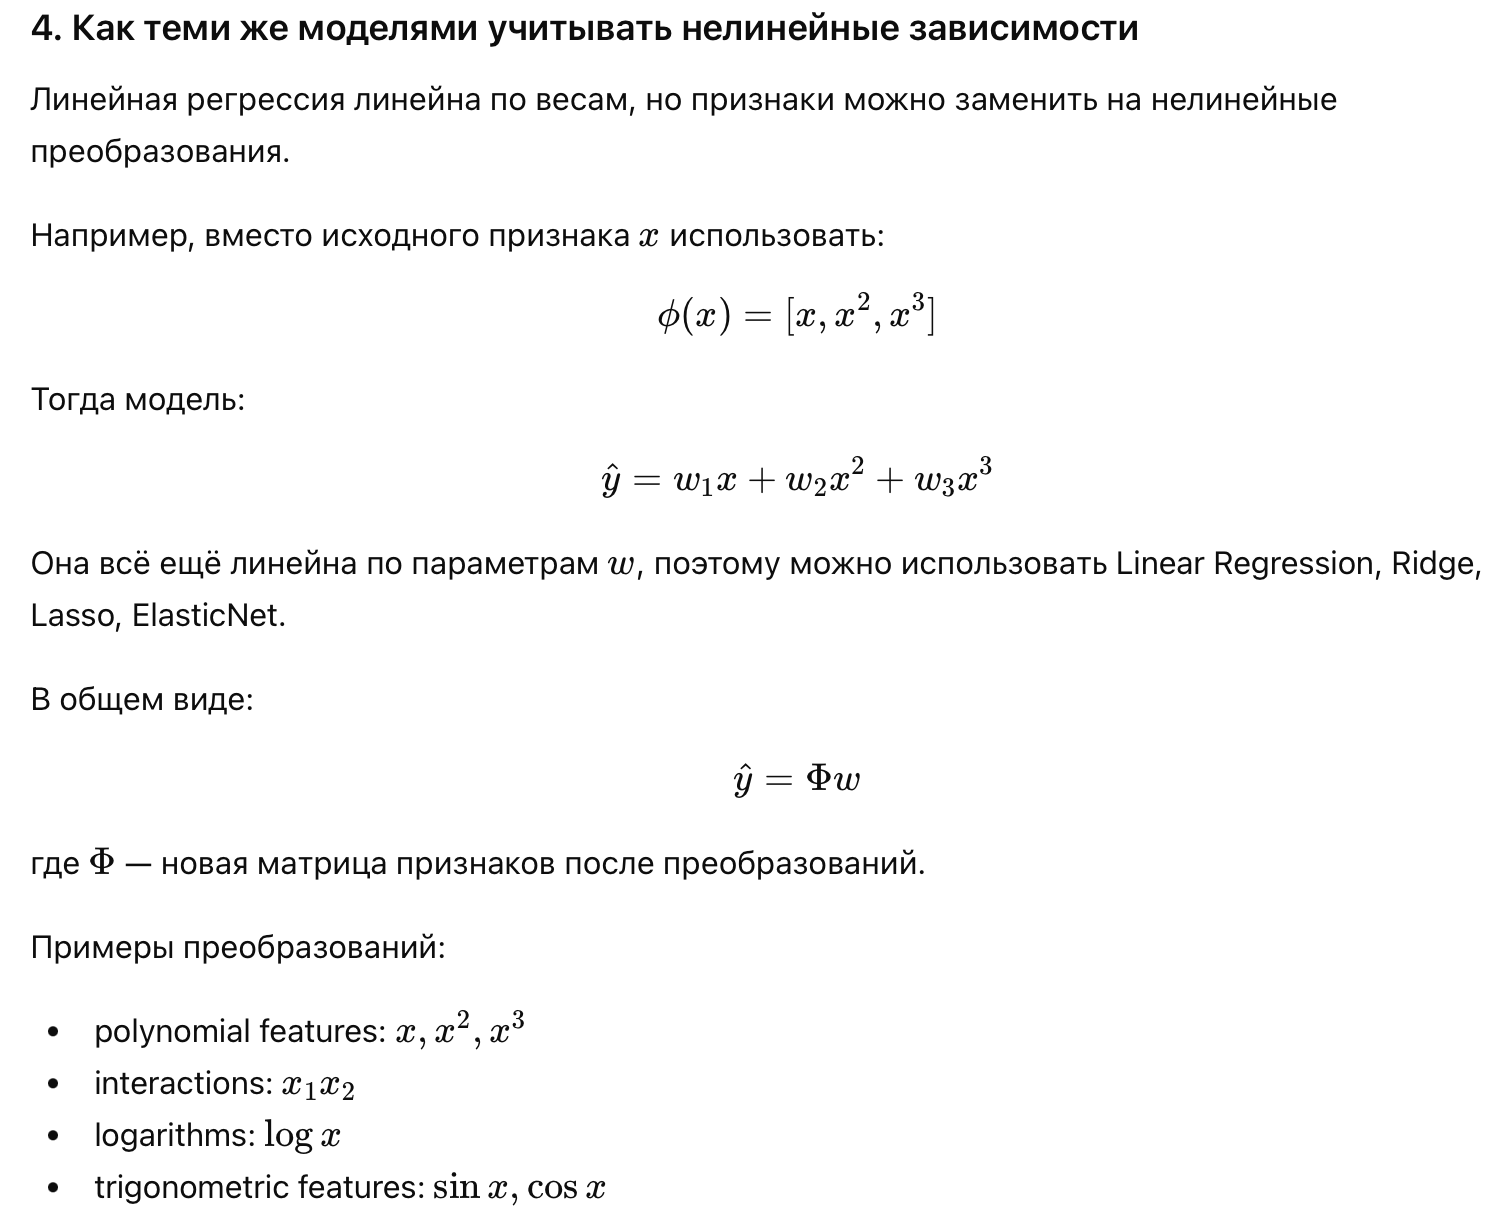

TASK 2

In [81]:
df = pd.read_json('./data/train.json')

In [82]:
test_df = pd.read_json('./data/test.json')

In [83]:
df = df[['bathrooms', 'bedrooms', 'interest_level', 'price', 'features']]

In [84]:
df = df.reset_index(drop=True)

In [85]:
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

TASK 3

In [86]:
df['features'].head()

0    [Dining Room, Pre-War, Laundry in Building, Di...
1    [Doorman, Elevator, Laundry in Building, Dishw...
2    [Doorman, Elevator, Laundry in Building, Laund...
3                                                   []
4    [Doorman, Elevator, Fitness Center, Laundry in...
Name: features, dtype: object

In [87]:
df['features_clean'] = df['features'].apply(
    lambda x: [feature.replace(' ', '') for feature in x]
)

In [88]:
df[['features', 'features_clean']].head()

,features,features_clean
0,"[Dining Room, Pre-War, Laundry in Building, Di...","[DiningRoom, Pre-War, LaundryinBuilding, Dishw..."
1,"[Doorman, Elevator, Laundry in Building, Dishw...","[Doorman, Elevator, LaundryinBuilding, Dishwas..."
2,"[Doorman, Elevator, Laundry in Building, Laund...","[Doorman, Elevator, LaundryinBuilding, Laundry..."
3,[],[]
4,"[Doorman, Elevator, Fitness Center, Laundry in...","[Doorman, Elevator, FitnessCenter, LaundryinBu..."


In [89]:
all_features = []

for _, row in df.iterrows():
    all_features.extend(row['features_clean'])

In [90]:
len(all_features)

262573

In [91]:
unique_features = set(all_features)

len(unique_features)

1531

In [92]:
from collections import Counter

feature_counter = Counter(all_features)

In [93]:
top_20 = [feature for feature, count in feature_counter.most_common(20)]

top_20

['Elevator',
 'HardwoodFloors',
 'CatsAllowed',
 'DogsAllowed',
 'Doorman',
 'Dishwasher',
 'NoFee',
 'LaundryinBuilding',
 'FitnessCenter',
 'Pre-War',
 'LaundryinUnit',
 'RoofDeck',
 'OutdoorSpace',
 'DiningRoom',
 'HighSpeedInternet',
 'Balcony',
 'SwimmingPool',
 'LaundryInBuilding',
 'NewConstruction',
 'Terrace']

In [94]:
for feature in top_20:
    df[feature] = df['features_clean'].apply(
        lambda x: 1 if feature in x else 0
    )

In [95]:
test_df['features_clean'] = test_df['features'].apply(
    lambda x: [feature.replace(' ', '') for feature in x]
)

for feature in top_20:
    test_df[feature] = test_df['features_clean'].apply(
        lambda x: 1 if feature in x else 0
    )

In [96]:
df[top_20].head()

,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,0,1,1,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0
1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0


In [97]:
feature_list = ['bathrooms', 'bedrooms'] + top_20

In [98]:
len(feature_list)

22

In [99]:
X = df[feature_list]
y = df['price']

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

In [101]:
feature_counter.most_common(21)

[('Elevator', 25398),
 ('HardwoodFloors', 23159),
 ('CatsAllowed', 23148),
 ('DogsAllowed', 21662),
 ('Doorman', 20497),
 ('Dishwasher', 20095),
 ('NoFee', 17806),
 ('LaundryinBuilding', 16093),
 ('FitnessCenter', 13000),
 ('Pre-War', 8978),
 ('LaundryinUnit', 8448),
 ('RoofDeck', 6423),
 ('OutdoorSpace', 5137),
 ('DiningRoom', 4901),
 ('HighSpeedInternet', 4225),
 ('Balcony', 2898),
 ('SwimmingPool', 2648),
 ('LaundryInBuilding', 2565),
 ('NewConstruction', 2507),
 ('Terrace', 2179),
 ('Exclusive', 2080)]

TASK 4

 Своя Linear Regression через SGD

In [102]:
class MyLinearRegression:
    def __init__(self, lr=0.01, epochs=1000, batch_size=64, random_state=21):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        X = np.c_[np.ones(X.shape[0]), X]

        rng = np.random.default_rng(self.random_state)
        self.weights = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            indices = rng.permutation(X.shape[0])

            for start in range(0, X.shape[0], self.batch_size):
                batch_idx = indices[start:start + self.batch_size]

                X_batch = X[batch_idx]
                y_batch = y[batch_idx]

                y_pred = X_batch @ self.weights
                grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)

                self.weights -= self.lr * grad

        return self

    def predict(self, X):
        X = np.array(X)
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.weights

Детерминистическая модель всегда дает один и тот же результат для одних и тех же входных данных и параметров.

SGD обычно стохастический, потому что он случайным образом перемешивает данные и выбирает партии.

Чтобы сделать SGD детерминированным, мы исправляем random_state.

R2 функция

In [103]:
def my_r2_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)

    return 1 - ss_res / ss_tot

In [104]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
result_R2 = pd.DataFrame(columns=['model', 'train', 'test'])

In [105]:
my_lr = MyLinearRegression(lr=0.01, epochs=1000, batch_size=64, random_state=21)

my_lr.fit(X_train, y_train)

my_train_pred = my_lr.predict(X_train)
my_test_pred = my_lr.predict(X_test)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: invalid va

Метрики своей модели

In [106]:
mae_train = mean_absolute_error(y_train, my_train_pred)
mae_test = mean_absolute_error(y_test, my_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, my_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, my_test_pred))

r2_train = my_r2_score(y_train, my_train_pred)
r2_test = my_r2_score(y_test, my_test_pred)

result_MAE.loc[len(result_MAE)] = ['my_linear_regression', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['my_linear_regression', rmse_train, rmse_test]
result_R2.loc[len(result_R2)] = ['my_linear_regression', r2_train, r2_test]

Все тоже самое но для skl регрессии

In [107]:
sk_lr = LinearRegression()

sk_lr.fit(X_train, y_train)

sk_train_pred = sk_lr.predict(X_train)
sk_test_pred = sk_lr.predict(X_test)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [108]:
mae_train = mean_absolute_error(y_train, sk_train_pred)
mae_test = mean_absolute_error(y_test, sk_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, sk_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, sk_test_pred))

r2_train = my_r2_score(y_train, sk_train_pred)
r2_test = my_r2_score(y_test, sk_test_pred)

result_MAE.loc[len(result_MAE)] = ['sklearn_linear_regression', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['sklearn_linear_regression', rmse_train, rmse_test]
result_R2.loc[len(result_R2)] = ['sklearn_linear_regression', r2_train, r2_test]

In [109]:
display(result_MAE)
display(result_RMSE)
display(result_R2)

,model,train,test
0,my_linear_regression,716.101109,711.309344
1,sklearn_linear_regression,713.555359,708.554495


,model,train,test
0,my_linear_regression,1037.971766,1026.482228
1,sklearn_linear_regression,1037.764309,1025.990632


,model,train,test
0,my_linear_regression,0.578335,0.585498
1,sklearn_linear_regression,0.578504,0.585895


Метрика 1: 711.31 против sklearn 708.55 — хуже примерно на 0.39%, это меньше 10%.
Метрика 2: 1026.48 против sklearn 1025.99 — хуже примерно на 0.05%, это меньше 10%.
R²: 0.5855 против sklearn 0.5859 — чуть хуже, но больше 0.4.

TASK 5

 Общий класс для Ridge / Lasso / ElasticNet

In [110]:
class MyRegularizedLinearRegression:
    def __init__(
        self, 
        lr=0.01, 
        epochs=1000, 
        batch_size=64, 
        alpha=0.01, 
        l1_ratio=0.5, 
        regularization='ridge',
        random_state=21
    ):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.regularization = regularization
        self.random_state = random_state

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        # bias column
        X = np.c_[np.ones(X.shape[0]), X]

        rng = np.random.default_rng(self.random_state)
        self.weights = np.zeros(X.shape[1])

        n_samples = X.shape[0]

        for _ in range(self.epochs):
            indices = rng.permutation(n_samples)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]

                X_batch = X[batch_idx]
                y_batch = y[batch_idx]

                y_pred = X_batch @ self.weights
                error = y_pred - y_batch

                grad = (2 / len(X_batch)) * (X_batch.T @ error)

                # do not regularize bias
                reg_weights = self.weights.copy()
                reg_weights[0] = 0

                if self.regularization == 'ridge':
                    grad += 2 * self.alpha * reg_weights

                elif self.regularization == 'lasso':
                    grad += self.alpha * np.sign(reg_weights)

                elif self.regularization == 'elasticnet':
                    l1_grad = self.l1_ratio * np.sign(reg_weights)
                    l2_grad = 2 * (1 - self.l1_ratio) * reg_weights
                    grad += self.alpha * (l1_grad + l2_grad)

                self.weights -= self.lr * grad

        return self

    def predict(self, X):
        X = np.array(X)
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.weights

Добавление метрик

In [111]:
def add_metrics(model_name, y_train, train_pred, y_test, test_pred):
    mae_train = mean_absolute_error(y_train, train_pred)
    mae_test = mean_absolute_error(y_test, test_pred)

    rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))

    r2_train = my_r2_score(y_train, train_pred)
    r2_test = my_r2_score(y_test, test_pred)

    result_MAE.loc[len(result_MAE)] = [model_name, mae_train, mae_test]
    result_RMSE.loc[len(result_RMSE)] = [model_name, rmse_train, rmse_test]
    result_R2.loc[len(result_R2)] = [model_name, r2_train, r2_test]

My Ridge

In [112]:
my_ridge = MyRegularizedLinearRegression(
    lr=0.01,
    epochs=1000,
    batch_size=64,
    alpha=0.01,
    regularization='ridge',
    random_state=21
)

my_ridge.fit(X_train, y_train)

my_ridge_train_pred = my_ridge.predict(X_train)
my_ridge_test_pred = my_ridge.predict(X_test)

add_metrics(
    'my_ridge',
    y_train,
    my_ridge_train_pred,
    y_test,
    my_ridge_test_pred
)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

My Lasso

In [113]:
my_lasso = MyRegularizedLinearRegression(
    lr=0.01,
    epochs=1000,
    batch_size=64,
    alpha=0.01,
    regularization='lasso',
    random_state=21
)

my_lasso.fit(X_train, y_train)

my_lasso_train_pred = my_lasso.predict(X_train)
my_lasso_test_pred = my_lasso.predict(X_test)

add_metrics(
    'my_lasso',
    y_train,
    my_lasso_train_pred,
    y_test,
    my_lasso_test_pred
)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

My ElasticNet

In [114]:
my_elastic = MyRegularizedLinearRegression(
    lr=0.01,
    epochs=1000,
    batch_size=64,
    alpha=0.01,
    l1_ratio=0.5,
    regularization='elasticnet',
    random_state=21
)

my_elastic.fit(X_train, y_train)

my_elastic_train_pred = my_elastic.predict(X_train)
my_elastic_test_pred = my_elastic.predict(X_test)

add_metrics(
    'my_elasticnet',
    y_train,
    my_elastic_train_pred,
    y_test,
    my_elastic_test_pred
)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

Все тоже самое но из skl

In [115]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [116]:
sk_ridge = Ridge(alpha=0.01)

sk_ridge.fit(X_train, y_train)

sk_ridge_train_pred = sk_ridge.predict(X_train)
sk_ridge_test_pred = sk_ridge.predict(X_test)

add_metrics(
    'sklearn_ridge',
    y_train,
    sk_ridge_train_pred,
    y_test,
    sk_ridge_test_pred
)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [117]:
sk_lasso = Lasso(alpha=0.01, max_iter=10000)

sk_lasso.fit(X_train, y_train)

sk_lasso_train_pred = sk_lasso.predict(X_train)
sk_lasso_test_pred = sk_lasso.predict(X_test)

add_metrics(
    'sklearn_lasso',
    y_train,
    sk_lasso_train_pred,
    y_test,
    sk_lasso_test_pred
)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [118]:
sk_elastic = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)

sk_elastic.fit(X_train, y_train)

sk_elastic_train_pred = sk_elastic.predict(X_train)
sk_elastic_test_pred = sk_elastic.predict(X_test)

add_metrics(
    'sklearn_elasticnet',
    y_train,
    sk_elastic_train_pred,
    y_test,
    sk_elastic_test_pred
)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [119]:
display(result_MAE)
display(result_RMSE)
display(result_R2)

,model,train,test
0,my_linear_regression,716.101109,711.309344
1,sklearn_linear_regression,713.555359,708.554495
2,my_ridge,715.106343,709.101114
3,my_lasso,716.097870,711.305430
4,my_elasticnet,715.397024,709.960041
5,sklearn_ridge,713.555320,708.554420
6,sklearn_lasso,713.548500,708.546305
7,sklearn_elasticnet,713.026791,707.392088


,model,train,test
0,my_linear_regression,1037.971766,1026.482228
1,sklearn_linear_regression,1037.764309,1025.990632
2,my_ridge,1038.612395,1025.987408
3,my_lasso,1037.971627,1026.479866
4,my_elasticnet,1038.059780,1025.956260
5,sklearn_ridge,1037.764309,1025.990598
6,sklearn_lasso,1037.764329,1025.986169
7,sklearn_elasticnet,1038.044754,1025.677098


,model,train,test
0,my_linear_regression,0.578335,0.585498
1,sklearn_linear_regression,0.578504,0.585895
2,my_ridge,0.577815,0.585898
3,my_lasso,0.578335,0.585500
4,my_elasticnet,0.578264,0.585923
5,sklearn_ridge,0.578504,0.585895
6,sklearn_lasso,0.578504,0.585899
7,sklearn_elasticnet,0.578276,0.586148


Task 6

Нормализация признаков важна для алгоритмов, которые полагаются на градиентный спуск, таких как линейная регрессия, Ridge, Lasso и ElasticNet, потому что различные масштабы признаков могут замедлить сходимость или привести к неправильным результатам.

Нормализация не требуется для моделей на основе деревьев, таких как деревья решений, потому что они не чувствительны к масштабированию признаков.

 Формула MinMaxScaler
x' = (x - min(x)) / (max(x) - min(x))

Формула StandardScaler
x' = (x - mean(x)) / std(x)

MinMaxScaler

In [120]:
class MyMinMaxScaler:
    def fit(self, X):
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
    
    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_)
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

Standart Scaler

In [121]:
class MyStandardScaler:
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
    
    def transform(self, X):
        return (X - self.mean_) / self.std_
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

Fit только на train

In [122]:
my_scaler = MyMinMaxScaler()

X_train_scaled = my_scaler.fit_transform(X_train)
X_test_scaled = my_scaler.transform(X_test)

Сравнение с skl

In [123]:
from sklearn.preprocessing import MinMaxScaler

sk_scaler = MinMaxScaler()

X_train_sk = sk_scaler.fit_transform(X_train)
X_test_sk = sk_scaler.transform(X_test)

In [124]:
np.allclose(X_train_scaled, X_train_sk)

True

In [125]:
from sklearn.preprocessing import StandardScaler

sk_std = StandardScaler()

X_train_std = sk_std.fit_transform(X_train)
X_test_std = sk_std.transform(X_test)

In [126]:
model_name = 'ridge_minmax'

In [127]:
model_name = 'ridge_standard'

TASK 7

My with minmax scaler

In [128]:
my_lr_minmax = MyLinearRegression(lr=0.01, epochs=1000, batch_size=64, random_state=21)
my_lr_minmax.fit(X_train_scaled, y_train)

train_pred = my_lr_minmax.predict(X_train_scaled)
test_pred = my_lr_minmax.predict(X_test_scaled)

add_metrics('my_linear_minmax', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: invalid va

In [129]:
my_ridge_minmax = MyRegularizedLinearRegression(
    lr=0.01, epochs=1000, batch_size=64,
    alpha=0.01, regularization='ridge', random_state=21
)

my_ridge_minmax.fit(X_train_scaled, y_train)

train_pred = my_ridge_minmax.predict(X_train_scaled)
test_pred = my_ridge_minmax.predict(X_test_scaled)

add_metrics('my_ridge_minmax', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

In [130]:
my_lasso_minmax = MyRegularizedLinearRegression(
    lr=0.01, epochs=1000, batch_size=64,
    alpha=0.01, regularization='lasso', random_state=21
)

my_lasso_minmax.fit(X_train_scaled, y_train)

train_pred = my_lasso_minmax.predict(X_train_scaled)
test_pred = my_lasso_minmax.predict(X_test_scaled)

add_metrics('my_lasso_minmax', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

In [131]:
my_elastic_minmax = MyRegularizedLinearRegression(
    lr=0.01, epochs=1000, batch_size=64,
    alpha=0.01, l1_ratio=0.5,
    regularization='elasticnet', random_state=21
)

my_elastic_minmax.fit(X_train_scaled, y_train)

train_pred = my_elastic_minmax.predict(X_train_scaled)
test_pred = my_elastic_minmax.predict(X_test_scaled)

add_metrics('my_elasticnet_minmax', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

SKL with minmax scaler

In [132]:
sk_linear_minmax = LinearRegression()
sk_linear_minmax.fit(X_train_scaled, y_train)

train_pred = sk_linear_minmax.predict(X_train_scaled)
test_pred = sk_linear_minmax.predict(X_test_scaled)

add_metrics('sklearn_linear_minmax', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [133]:
sk_ridge_minmax = Ridge(alpha=0.01)
sk_ridge_minmax.fit(X_train_scaled, y_train)

train_pred = sk_ridge_minmax.predict(X_train_scaled)
test_pred = sk_ridge_minmax.predict(X_test_scaled)

add_metrics('sklearn_ridge_minmax', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [134]:
sk_lasso_minmax = Lasso(alpha=0.01, max_iter=10000)
sk_lasso_minmax.fit(X_train_scaled, y_train)

train_pred = sk_lasso_minmax.predict(X_train_scaled)
test_pred = sk_lasso_minmax.predict(X_test_scaled)

add_metrics('sklearn_lasso_minmax', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [135]:
sk_elastic_minmax = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
sk_elastic_minmax.fit(X_train_scaled, y_train)

train_pred = sk_elastic_minmax.predict(X_train_scaled)
test_pred = sk_elastic_minmax.predict(X_test_scaled)

add_metrics('sklearn_elasticnet_minmax', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

My with std scaler

In [136]:
my_lr_standard = MyLinearRegression(lr=0.01, epochs=1000, batch_size=64, random_state=21)
my_lr_standard.fit(X_train_std, y_train)

train_pred = my_lr_standard.predict(X_train_std)
test_pred = my_lr_standard.predict(X_test_std)

add_metrics('my_linear_standard', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: invalid va

In [137]:
my_ridge_standard = MyRegularizedLinearRegression(
    lr=0.01, epochs=1000, batch_size=64,
    alpha=0.01, regularization='ridge', random_state=21
)

my_ridge_standard.fit(X_train_std, y_train)

train_pred = my_ridge_standard.predict(X_train_std)
test_pred = my_ridge_standard.predict(X_test_std)

add_metrics('my_ridge_standard', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

In [138]:
my_lasso_standard = MyRegularizedLinearRegression(
    lr=0.01, epochs=1000, batch_size=64,
    alpha=0.01, regularization='lasso', random_state=21
)

my_lasso_standard.fit(X_train_std, y_train)

train_pred = my_lasso_standard.predict(X_train_std)
test_pred = my_lasso_standard.predict(X_test_std)

add_metrics('my_lasso_standard', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

In [139]:
my_elastic_standard = MyRegularizedLinearRegression(
    lr=0.01, epochs=1000, batch_size=64,
    alpha=0.01, l1_ratio=0.5,
    regularization='elasticnet', random_state=21
)

my_elastic_standard.fit(X_train_std, y_train)

train_pred = my_elastic_standard.predict(X_train_std)
test_pred = my_elastic_standard.predict(X_test_std)

add_metrics('my_elasticnet_standard', y_train, train_pred, y_test, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

SKL with std scaler

In [140]:
sk_linear_standard = LinearRegression()
sk_linear_standard.fit(X_train_std, y_train)

train_pred = sk_linear_standard.predict(X_train_std)
test_pred = sk_linear_standard.predict(X_test_std)

add_metrics('sklearn_linear_standard', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [141]:
sk_ridge_standard = Ridge(alpha=0.01)
sk_ridge_standard.fit(X_train_std, y_train)

train_pred = sk_ridge_standard.predict(X_train_std)
test_pred = sk_ridge_standard.predict(X_test_std)

add_metrics('sklearn_ridge_standard', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [142]:
sk_lasso_standard = Lasso(alpha=0.01, max_iter=10000)
sk_lasso_standard.fit(X_train_std, y_train)

train_pred = sk_lasso_standard.predict(X_train_std)
test_pred = sk_lasso_standard.predict(X_test_std)

add_metrics('sklearn_lasso_standard', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [143]:
sk_elastic_standard = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
sk_elastic_standard.fit(X_train_std, y_train)

train_pred = sk_elastic_standard.predict(X_train_std)
test_pred = sk_elastic_standard.predict(X_test_std)

add_metrics('sklearn_elasticnet_standard', y_train, train_pred, y_test, test_pred)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [144]:
display(result_MAE)
display(result_RMSE)
display(result_R2)

,model,train,test
0,my_linear_regression,716.101109,711.309344
1,sklearn_linear_regression,713.555359,708.554495
2,my_ridge,715.106343,709.101114
3,my_lasso,716.097870,711.305430
4,my_elasticnet,715.397024,709.960041
5,sklearn_ridge,713.555320,708.554420
6,sklearn_lasso,713.548500,708.546305
7,sklearn_elasticnet,713.026791,707.392088
8,my_linear_minmax,713.153888,708.196997
9,my_ridge_minmax,798.930698,792.141711


,model,train,test
0,my_linear_regression,1037.971766,1026.482228
1,sklearn_linear_regression,1037.764309,1025.990632
2,my_ridge,1038.612395,1025.987408
3,my_lasso,1037.971627,1026.479866
4,my_elasticnet,1038.059780,1025.956260
5,sklearn_ridge,1037.764309,1025.990598
6,sklearn_lasso,1037.764329,1025.986169
7,sklearn_elasticnet,1038.044754,1025.677098
8,my_linear_minmax,1037.817831,1026.076421
9,my_ridge_minmax,1186.002278,1181.427705


,model,train,test
0,my_linear_regression,0.578335,0.585498
1,sklearn_linear_regression,0.578504,0.585895
2,my_ridge,0.577815,0.585898
3,my_lasso,0.578335,0.585500
4,my_elasticnet,0.578264,0.585923
5,sklearn_ridge,0.578504,0.585895
6,sklearn_lasso,0.578504,0.585899
7,sklearn_elasticnet,0.578276,0.586148
8,my_linear_minmax,0.578460,0.585826
9,my_ridge_minmax,0.449487,0.450917


Task 8

In [145]:
X_poly_base = df[['bathrooms', 'bedrooms']]
y = df['price']

In [146]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly_base, y, test_size=0.2, random_state=21
)

In [147]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train_p)
X_test_poly = poly.transform(X_test_p)

In [148]:
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

In [149]:
my_lr_poly = MyLinearRegression(lr=0.0001, epochs=1000, batch_size=64, random_state=21)

my_lr_poly.fit(X_train_poly, y_train_p)

train_pred = my_lr_poly.predict(X_train_poly)
test_pred = my_lr_poly.predict(X_test_poly)

add_metrics('my_linear_poly', y_train_p, train_pred, y_test_p, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:26: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * X_batch.T @ (y_pred - y_batch)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/2963033349.py:27: RuntimeWarning: invalid va

In [150]:
my_ridge_poly = MyRegularizedLinearRegression(
    lr=0.0001, epochs=1000, batch_size=64,
    alpha=0.1, regularization='ridge', random_state=21
)

my_ridge_poly.fit(X_train_poly, y_train_p)

train_pred = my_ridge_poly.predict(X_train_poly)
test_pred = my_ridge_poly.predict(X_test_poly)

add_metrics('my_ridge_poly', y_train_p, train_pred, y_test_p, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

In [151]:
my_lasso_poly = MyRegularizedLinearRegression(
    lr=0.0001, epochs=1000, batch_size=64,
    alpha=1, regularization='lasso', random_state=21
)

my_lasso_poly.fit(X_train_poly, y_train_p)

train_pred = my_lasso_poly.predict(X_train_poly)
test_pred = my_lasso_poly.predict(X_test_poly)

add_metrics('my_lasso_poly', y_train_p, train_pred, y_test_p, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

In [152]:
my_elastic_poly = MyRegularizedLinearRegression(
    lr=0.0001, epochs=1000, batch_size=64,
    alpha=0.1, l1_ratio=0.5,
    regularization='elasticnet', random_state=21
)

my_elastic_poly.fit(X_train_poly, y_train_p)

train_pred = my_elastic_poly.predict(X_train_poly)
test_pred = my_elastic_poly.predict(X_test_poly)

add_metrics('my_elastic_poly', y_train_p, train_pred, y_test_p, test_pred)

/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: overflow encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:41: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ self.weights
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: divide by zero encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: overflow encountered in matmul
  grad = (2 / len(X_batch)) * (X_batch.T @ error)
/var/folders/mv/cndzwjh57k553y8tywr8tmg80000gn/T/ipykernel_11340/698777373.py:44: RuntimeWarning: invalid value encountered in matmul
  

In [153]:
display(result_MAE)
display(result_RMSE)
display(result_R2)

,model,train,test
0,my_linear_regression,7.161011e+02,7.113093e+02
1,sklearn_linear_regression,7.135554e+02,7.085545e+02
2,my_ridge,7.151063e+02,7.091011e+02
3,my_lasso,7.160979e+02,7.113054e+02
4,my_elasticnet,7.153970e+02,7.099600e+02
5,sklearn_ridge,7.135553e+02,7.085544e+02
6,sklearn_lasso,7.135485e+02,7.085463e+02
7,sklearn_elasticnet,7.130268e+02,7.073921e+02
8,my_linear_minmax,7.131539e+02,7.081970e+02
9,my_ridge_minmax,7.989307e+02,7.921417e+02


,model,train,test
0,my_linear_regression,1.037972e+03,1.026482e+03
1,sklearn_linear_regression,1.037764e+03,1.025991e+03
2,my_ridge,1.038612e+03,1.025987e+03
3,my_lasso,1.037972e+03,1.026480e+03
4,my_elasticnet,1.038060e+03,1.025956e+03
5,sklearn_ridge,1.037764e+03,1.025991e+03
6,sklearn_lasso,1.037764e+03,1.025986e+03
7,sklearn_elasticnet,1.038045e+03,1.025677e+03
8,my_linear_minmax,1.037818e+03,1.026076e+03
9,my_ridge_minmax,1.186002e+03,1.181428e+03


,model,train,test
0,my_linear_regression,5.783353e-01,5.854980e-01
1,sklearn_linear_regression,5.785038e-01,5.858949e-01
2,my_ridge,5.778146e-01,5.858975e-01
3,my_lasso,5.783354e-01,5.854999e-01
4,my_elasticnet,5.782638e-01,5.859227e-01
5,sklearn_ridge,5.785038e-01,5.858950e-01
6,sklearn_lasso,5.785038e-01,5.858985e-01
7,sklearn_elasticnet,5.782760e-01,5.861480e-01
8,my_linear_minmax,5.784603e-01,5.858257e-01
9,my_ridge_minmax,4.494874e-01,4.509169e-01


Task 9

In [154]:
mean_value = y_train.mean()

train_pred = np.full(len(y_train), mean_value)
test_pred = np.full(len(y_test), mean_value)

add_metrics('naive_mean', y_train, train_pred, y_test, test_pred)

In [155]:
median_value = y_train.median()

train_pred = np.full(len(y_train), median_value)
test_pred = np.full(len(y_test), median_value)

add_metrics('naive_median', y_train, train_pred, y_test, test_pred)

In [156]:
display(result_MAE)
display(result_RMSE)
display(result_R2)

,model,train,test
0,my_linear_regression,7.161011e+02,7.113093e+02
1,sklearn_linear_regression,7.135554e+02,7.085545e+02
2,my_ridge,7.151063e+02,7.091011e+02
3,my_lasso,7.160979e+02,7.113054e+02
4,my_elasticnet,7.153970e+02,7.099600e+02
5,sklearn_ridge,7.135553e+02,7.085544e+02
6,sklearn_lasso,7.135485e+02,7.085463e+02
7,sklearn_elasticnet,7.130268e+02,7.073921e+02
8,my_linear_minmax,7.131539e+02,7.081970e+02
9,my_ridge_minmax,7.989307e+02,7.921417e+02


,model,train,test
0,my_linear_regression,1.037972e+03,1.026482e+03
1,sklearn_linear_regression,1.037764e+03,1.025991e+03
2,my_ridge,1.038612e+03,1.025987e+03
3,my_lasso,1.037972e+03,1.026480e+03
4,my_elasticnet,1.038060e+03,1.025956e+03
5,sklearn_ridge,1.037764e+03,1.025991e+03
6,sklearn_lasso,1.037764e+03,1.025986e+03
7,sklearn_elasticnet,1.038045e+03,1.025677e+03
8,my_linear_minmax,1.037818e+03,1.026076e+03
9,my_ridge_minmax,1.186002e+03,1.181428e+03


,model,train,test
0,my_linear_regression,5.783353e-01,5.854980e-01
1,sklearn_linear_regression,5.785038e-01,5.858949e-01
2,my_ridge,5.778146e-01,5.858975e-01
3,my_lasso,5.783354e-01,5.854999e-01
4,my_elasticnet,5.782638e-01,5.859227e-01
5,sklearn_ridge,5.785038e-01,5.858950e-01
6,sklearn_lasso,5.785038e-01,5.858985e-01
7,sklearn_elasticnet,5.782760e-01,5.861480e-01
8,my_linear_minmax,5.784603e-01,5.858257e-01
9,my_ridge_minmax,4.494874e-01,4.509169e-01


Task 10

In [157]:
print("MAE")
display(result_MAE)

print("RMSE")
display(result_RMSE)

print("R2")
display(result_R2)

MAE


,model,train,test
0,my_linear_regression,7.161011e+02,7.113093e+02
1,sklearn_linear_regression,7.135554e+02,7.085545e+02
2,my_ridge,7.151063e+02,7.091011e+02
3,my_lasso,7.160979e+02,7.113054e+02
4,my_elasticnet,7.153970e+02,7.099600e+02
5,sklearn_ridge,7.135553e+02,7.085544e+02
6,sklearn_lasso,7.135485e+02,7.085463e+02
7,sklearn_elasticnet,7.130268e+02,7.073921e+02
8,my_linear_minmax,7.131539e+02,7.081970e+02
9,my_ridge_minmax,7.989307e+02,7.921417e+02


RMSE


,model,train,test
0,my_linear_regression,1.037972e+03,1.026482e+03
1,sklearn_linear_regression,1.037764e+03,1.025991e+03
2,my_ridge,1.038612e+03,1.025987e+03
3,my_lasso,1.037972e+03,1.026480e+03
4,my_elasticnet,1.038060e+03,1.025956e+03
5,sklearn_ridge,1.037764e+03,1.025991e+03
6,sklearn_lasso,1.037764e+03,1.025986e+03
7,sklearn_elasticnet,1.038045e+03,1.025677e+03
8,my_linear_minmax,1.037818e+03,1.026076e+03
9,my_ridge_minmax,1.186002e+03,1.181428e+03


R2


,model,train,test
0,my_linear_regression,5.783353e-01,5.854980e-01
1,sklearn_linear_regression,5.785038e-01,5.858949e-01
2,my_ridge,5.778146e-01,5.858975e-01
3,my_lasso,5.783354e-01,5.854999e-01
4,my_elasticnet,5.782638e-01,5.859227e-01
5,sklearn_ridge,5.785038e-01,5.858950e-01
6,sklearn_lasso,5.785038e-01,5.858985e-01
7,sklearn_elasticnet,5.782760e-01,5.861480e-01
8,my_linear_minmax,5.784603e-01,5.858257e-01
9,my_ridge_minmax,4.494874e-01,4.509169e-01


Best model:
ElasticNet (особенно sklearn_elasticnet / my_elasticnet_standard)
Most stable model:
Linear Regression, так как её качество практически не меняется при различных способах масштабирования признаков

ElasticNet лучше → баланс L1 + L2 регуляризации
Linear стабильна → не чувствительна к масштабу признаков
MinMax ухудшил → из-за чувствительности SGD к масштабу и alpha

Polynomial — гигантские значения, отрицательный R² (переобучение)
Ridge / ElasticNet + MinMax — сильная деградация.  (переобучение)